In [37]:
import numpy as np
import pandas as pd

In [38]:
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [39]:
X = df.drop('medv', axis = 1)
y = df['medv']

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 42, test_size = 0.2)

In [41]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score, KFold


In [42]:
knn = KNeighborsRegressor()

In [43]:
knn.fit(X_train,y_train)

KNeighborsRegressor()

In [44]:
y_pred = knn.predict(X_test)

In [45]:
y_pred

array([24.54, 29.34, 14.6 , 28.  , 16.74, 31.88, 19.74, 16.06, 18.02,
       21.18, 23.38, 20.04, 12.42, 21.34, 23.7 , 22.22, 19.04, 14.06,
       35.14, 10.6 , 25.86, 29.34, 16.78, 21.08, 18.88, 22.78, 22.46,
       11.46, 23.38, 21.94, 22.68, 23.44, 10.3 , 30.04, 17.54, 21.12,
       21.66, 25.98, 22.52, 28.  , 21.18, 30.46, 38.16, 22.4 , 24.84,
       12.6 , 19.46, 28.  , 19.8 , 21.56, 22.44, 34.7 , 17.96, 21.18,
       30.36, 21.38, 12.5 , 35.14, 21.74, 21.12, 25.3 , 38.82, 29.1 ,
       14.3 , 30.46, 23.38, 12.26, 25.3 , 35.04, 13.36, 20.58, 22.52,
       17.66, 25.3 , 22.46,  8.98, 19.68, 38.16, 10.94, 14.08, 22.88,
       15.96, 24.32, 12.24, 21.46, 31.98, 14.16, 21.66, 26.04, 17.86,
       22.98, 14.7 , 17.48, 20.36, 24.76, 17.86, 30.16,  8.7 , 10.76,
       11.92, 21.8 , 22.46])

In [46]:
kfold = KFold(n_splits = 5, shuffle = True, random_state = 42)
score = cross_val_score(knn, X,y, cv = kfold, scoring = 'r2')

In [47]:
np.round(score.mean(), 2)

np.float64(0.54)

In [48]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
display(f"R-squared on testing data: {r2:.2f}")

'R-squared on testing data: 0.65'

# GridSearch CV

In [49]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor()

In [50]:
param_grid = {
    'n_neighbors': [1,3,5,7,9,12,15,18,21],
    'weights': ['uniform', 'distance'],
    'algorithm' :['ball_trees','kd_tree', 'brute'],
    'p' : [1,2]
}

In [51]:
from sklearn.model_selection import GridSearchCV

gcv = GridSearchCV(knn, param_grid, scoring = 'r2',refit = True, cv = kfold, verbose = 2)

In [52]:
gcv.fit(X_train,y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END algorithm=ball_trees, n_neighbors=1, p=1, weights=uniform; total time=   0.0s
[CV] END algorithm=ball_trees, n_neighbors=1, p=1, weights=uniform; total time=   0.0s
[CV] END algorithm=ball_trees, n_neighbors=1, p=1, weights=uniform; total time=   0.0s
[CV] END algorithm=ball_trees, n_neighbors=1, p=1, weights=uniform; total time=   0.0s
[CV] END algorithm=ball_trees, n_neighbors=1, p=1, weights=uniform; total time=   0.0s
[CV] END algorithm=ball_trees, n_neighbors=1, p=1, weights=distance; total time=   0.0s
[CV] END algorithm=ball_trees, n_neighbors=1, p=1, weights=distance; total time=   0.0s
[CV] END algorithm=ball_trees, n_neighbors=1, p=1, weights=distance; total time=   0.0s
[CV] END algorithm=ball_trees, n_neighbors=1, p=1, weights=distance; total time=   0.0s
[CV] END algorithm=ball_trees, n_neighbors=1, p=1, weights=distance; total time=   0.0s
[CV] END algorithm=ball_trees, n_neighbors=1, p=2, weights=uni

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
180 fits failed out of a total of 540.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
180 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/util

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=KNeighborsRegressor(),
             param_grid={'algorithm': ['ball_trees', 'kd_tree', 'brute'],
                         'n_neighbors': [1, 3, 5, 7, 9, 12, 15, 18, 21],
                         'p': [1, 2], 'weights': ['uniform', 'distance']},
             scoring='r2', verbose=2)

In [53]:
gcv.best_params_

{'algorithm': 'kd_tree', 'n_neighbors': 5, 'p': 1, 'weights': 'distance'}

In [54]:
gcv.best_score_

np.float64(0.6246716029610424)

In [55]:
gcv.cv_results_

{'mean_fit_time': array([0.00093694, 0.00098372, 0.00099597, 0.00099411, 0.00091486,
        0.00063143, 0.00059509, 0.00077133, 0.00073481, 0.00063047,
        0.0006144 , 0.00059981, 0.00062957, 0.00084558, 0.00425382,
        0.00327902, 0.00514746, 0.00501375, 0.0037374 , 0.00374761,
        0.00543165, 0.00295367, 0.00364094, 0.00246205, 0.00207   ,
        0.00119519, 0.0011075 , 0.00095577, 0.00084953, 0.00085812,
        0.00086126, 0.00089397, 0.00151806, 0.00097275, 0.00091658,
        0.00138254, 0.00273714, 0.00316067, 0.00270729, 0.00268211,
        0.00251656, 0.0033565 , 0.00254493, 0.00252318, 0.00242753,
        0.0026937 , 0.00416398, 0.00429344, 0.00252743, 0.00268326,
        0.01351624, 0.01415858, 0.01908121, 0.00493178, 0.00487657,
        0.00428991, 0.00433784, 0.00418429, 0.00366468, 0.00442595,
        0.00372458, 0.00508251, 0.00440359, 0.0037775 , 0.00402942,
        0.00392504, 0.0036581 , 0.00350776, 0.00390849, 0.00394979,
        0.0038269 , 0.00368876,

In [56]:
pd.DataFrame(gcv.cv_results_)[['param_algorithm','param_n_neighbors',	'param_p', 'param_weights', 'mean_test_score']].sort_values('mean_test_score',ascending=False)


,param_algorithm,param_n_neighbors,param_p,param_weights,mean_test_score
81,brute,5,1,distance,0.624672
45,kd_tree,5,1,distance,0.624672
49,kd_tree,7,1,distance,0.604068
85,brute,7,1,distance,0.604068
89,brute,9,1,distance,0.588247
...,...,...,...,...,...
31,ball_trees,18,2,distance,NaN
32,ball_trees,21,1,uniform,NaN
33,ball_trees,21,1,distance,NaN
34,ball_trees,21,2,uniform,NaN


In [57]:
best_knn_model = gcv.best_estimator_
y_pred_tuned = best_knn_model.predict(X_test)
r2_tuned = r2_score(y_test, y_pred_tuned)
display(f"R-squared on testing data with tuned model: {r2_tuned:.2f}")

'R-squared on testing data with tuned model: 0.71'

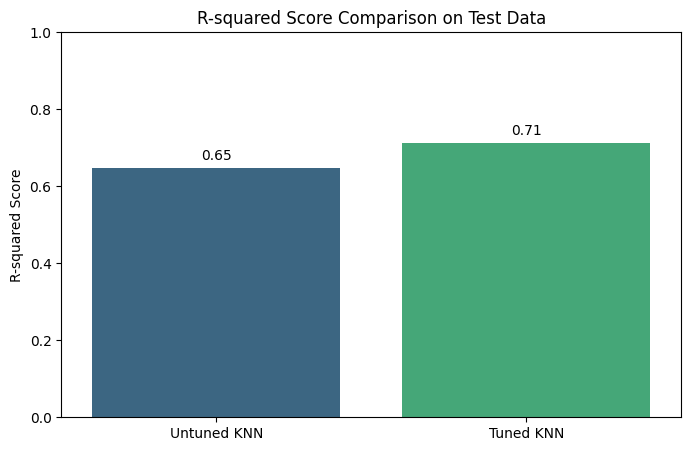

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data for plotting
models = ['Untuned KNN', 'Tuned KNN']
r2_scores = [r2, r2_tuned]

# Create a bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=r2_scores, hue=models, palette='viridis', legend=False)
plt.title('R-squared Score Comparison on Test Data')
plt.ylabel('R-squared Score')
plt.ylim(0, 1) # R-squared typically ranges from 0 to 1

# Add score values on top of the bars
for index, value in enumerate(r2_scores):
    plt.text(index, value + 0.02, f'{value:.2f}', ha='center')

plt.show()

# RandomizedSearch CV

In [60]:
from sklearn.model_selection import RandomizedSearchCV

In [61]:
rcv = RandomizedSearchCV(knn, param_grid, scoring = 'r2', refit = True, cv = kfold , verbose = 2)

In [62]:
rcv.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END algorithm=kd_tree, n_neighbors=21, p=1, weights=distance; total time=   0.0s
[CV] END algorithm=kd_tree, n_neighbors=21, p=1, weights=distance; total time=   0.0s
[CV] END algorithm=kd_tree, n_neighbors=21, p=1, weights=distance; total time=   0.0s
[CV] END algorithm=kd_tree, n_neighbors=21, p=1, weights=distance; total time=   0.0s
[CV] END algorithm=kd_tree, n_neighbors=21, p=1, weights=distance; total time=   0.0s
[CV] END algorithm=brute, n_neighbors=12, p=1, weights=distance; total time=   0.0s
[CV] END algorithm=brute, n_neighbors=12, p=1, weights=distance; total time=   0.1s
[CV] END algorithm=brute, n_neighbors=12, p=1, weights=distance; total time=   0.0s
[CV] END algorithm=brute, n_neighbors=12, p=1, weights=distance; total time=   0.0s
[CV] END algorithm=brute, n_neighbors=12, p=1, weights=distance; total time=   0.0s
[CV] END algorithm=kd_tree, n_neighbors=18, p=2, weights=uniform; total time=   0.0s
[CV]

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=KNeighborsRegressor(),
                   param_distributions={'algorithm': ['ball_trees', 'kd_tree',
                                                      'brute'],
                                        'n_neighbors': [1, 3, 5, 7, 9, 12, 15,
                                                        18, 21],
                                        'p': [1, 2],
                                        'weights': ['uniform', 'distance']},
                   scoring='r2', verbose=2)

In [63]:
rcv.best_score_

np.float64(0.6040677637149089)

In [64]:
rcv.best_estimator_

KNeighborsRegressor(algorithm='kd_tree', n_neighbors=7, p=1, weights='distance')

In [65]:
rcv.best_params_

{'weights': 'distance', 'p': 1, 'n_neighbors': 7, 'algorithm': 'kd_tree'}